<a href="https://colab.research.google.com/github/nicopicomoco-sekihan-80/Antencoder-AntVLA/blob/main/v5/version5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# AntVLA V5
# PHASE 0: Clean GPU Environment
# ============================================================

import os
import sys
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python :", sys.version)
print("PyTorch:", torch.__version__)

print("\n=== CUDA ===")
print("available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. "
        "V5 experiment requires GPU."
    )

device = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))
print(
    "VRAM:",
    round(
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3,
        2
    ),
    "GB"
)

# Clean Python / CUDA cache
gc.collect()
torch.cuda.empty_cache()

print("\nGPU environment: READY")


Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128

=== CUDA ===
available: True
GPU: Tesla T4
VRAM: 14.56 GB

GPU environment: READY


In [2]:
# ============================================================
# V5 CONFIG
# ============================================================

class V5Config:

    # ----------------------------------------
    # Language
    # ----------------------------------------

    language_d_model = 128
    language_nhead = 4
    language_layers = 2
    language_ffn = 256
    language_output_dim = 512

    # ----------------------------------------
    # Object Teacher
    # ----------------------------------------

    object_teacher_dim = 512
    object_teacher_name = "mobileclip_s0"

    # ----------------------------------------
    # V / A / S
    # ----------------------------------------

    visual_dim = 32
    action_dim = 32
    state_dim = 8

    latent_dim_each = 128
    shared_latent_dim = 384

    # ----------------------------------------
    # Decoder
    # ----------------------------------------

    decoder_d_model = 128
    decoder_layers = 2

    # ----------------------------------------
    # Experiment
    # ----------------------------------------

    seed = 42


cfg = V5Config()

print("=== V5 CONFIG ===")

for key, value in vars(cfg).items():
    print(f"{key}: {value}")


=== V5 CONFIG ===


In [3]:
# ============================================================
# Reproducibility
# ============================================================

import random
import numpy as np

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", cfg.seed)


Seed: 42


In [6]:
# ============================================================
# V5 Phase 0.5
# Install MobileCLIP from source
# ============================================================

%cd /content

!rm -rf MobileCLIP

!git clone -q https://github.com/apple/ml-mobileclip.git MobileCLIP

%cd /content/MobileCLIP

!pip install -q -e .


/content
/content/MobileCLIP
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.3 MB/s eta 0:00:00


In [7]:
# ============================================================
# Verify
# ============================================================

import sys
import torch
import mobileclip

print("Python:")
print(sys.version)

print("\nExecutable:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("\nMobileCLIP:")
print(mobileclip.__file__)


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Python:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Executable:
/usr/bin/python3

PyTorch:
2.11.0+cu128

CUDA:
True
GPU: Tesla T4

MobileCLIP:
/content/MobileCLIP/mobileclip/__init__.py


In [9]:
# ============================================================
# V5 Phase 1
# Download MobileCLIP-S0 checkpoint
# ============================================================

import os

CHECKPOINT_DIR = "/content/v5_checkpoints"
CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "mobileclip_s0.pt"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print("Checkpoint path:")
print(CHECKPOINT)


Checkpoint path:
/content/v5_checkpoints/mobileclip_s0.pt


In [10]:
# ============================================================
# Download S0
# ============================================================

!pip install -q huggingface_hub


In [11]:
from huggingface_hub import hf_hub_download

print("Downloading MobileCLIP-S0...")

downloaded_path = hf_hub_download(
    repo_id="apple/MobileCLIP-S0",
    filename="mobileclip_s0.pt",
    local_dir=CHECKPOINT_DIR,
)

print("\nDownloaded:")
print(downloaded_path)

print("\nSize:")
print(
    round(
        os.path.getsize(downloaded_path)
        / 1024**2,
        1
    ),
    "MB"
)


mobileclip_s0.pt: reconstructing file:   0%|          |  0.00B /  216MB            

mobileclip_s0.pt: downloading bytes:           |  0.00B            


Downloaded:
/content/v5_checkpoints/mobileclip_s0.pt

Size:
205.9 MB


In [12]:
import os

print("exists:", os.path.exists(CHECKPOINT))

if os.path.exists(CHECKPOINT):
    print(
        "size:",
        round(
            os.path.getsize(CHECKPOINT)
            / 1024**2,
            1
        ),
        "MB"
    )


exists: True
size: 205.9 MB


In [13]:
# ============================================================
# MobileCLIP-S0
# Object Teacher
# ============================================================

import mobileclip

MOBILECLIP_CKPT = (
    "/content/v5_checkpoints/"
    "mobileclip_s0.pt"
)

if not os.path.exists(MOBILECLIP_CKPT):
    raise FileNotFoundError(
        MOBILECLIP_CKPT
    )

print(
    "Loading MobileCLIP-S0..."
)

mobileclip_model, _, preprocess = (
    mobileclip.create_model_and_transforms(
        "mobileclip_s0",
        pretrained=MOBILECLIP_CKPT,
        device=device,
    )
)

mobileclip_model = (
    mobileclip_model
    .to(device)
    .eval()
)

# Freeze teacher
for p in mobileclip_model.parameters():
    p.requires_grad = False

print("MobileCLIP-S0: READY")
print("Device:", device)


Loading MobileCLIP-S0...
MobileCLIP-S0: READY
Device: cuda


In [15]:
# ============================================================
# V5 Phase 2
# LIBERO / LeRobot
# ============================================================

!pip install -q lerobot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.4 MB/s eta 0:00:00


In [16]:
import lerobot

print("LeRobot:")
print(lerobot.__file__)


LeRobot:
/usr/local/lib/python3.13/dist-packages/lerobot/__init__.py


In [17]:
from huggingface_hub import list_datasets

results = list(
    list_datasets(
        search="libero",
        limit=20
    )
)

for x in results:
    print(x.id)


fangqi/libero
yifengzhu-hf/LIBERO-datasets
lerobot/libero
openvla/modified_libero_rlds
yygx/libero44_dataset_converted_externally_to_rlds_to_hg
yygx/libero44_KITCHEN_SCENE1_open_the_top_drawer_of_the_cabinet
yygx/libero44_KITCHEN_SCENE10_close_the_top_drawer_of_the_cabinet
yygx/libero44_KITCHEN_SCENE1_put_the_black_bowl_on_the_plate
nhatcm/hf_libero_relation
physical-intelligence/libero
Felix-Zhenghao/libero
lerobot/libero_10_image
lerobot/libero_spatial_image
lerobot/libero_goal_image
lerobot/libero_object_image
jaswu51/libero
vo2yager/libero
droid-ai/libero
Felix-Zhenghao/new_libero
jesbu1/libero_90_rlds


In [18]:
# ============================================================
# V5 Phase 2.1
# Inspect LIBERO-10 Image Dataset
# ============================================================

from datasets import load_dataset

LIBERO_ID = "lerobot/libero_10_image"

print("Loading:")
print(LIBERO_ID)

ds = load_dataset(
    LIBERO_ID,
    split="train",
)

print("\n=== Dataset ===")
print(ds)

print("\n=== Features ===")
print(ds.features)

print("\n=== Columns ===")
print(ds.column_names)

print("\n=== Length ===")
print(len(ds))
# ============================================================
# Inspect first sample
# ============================================================

sample = ds[0]

print("\n=== FIRST SAMPLE ===")

for key, value in sample.items():

    print(f"\n[{key}]")
    print("type :", type(value))

    if hasattr(value, "shape"):
        print("shape:", value.shape)
        print("dtype:", getattr(value, "dtype", None))
    else:
        print("value:", value)


Loading:
lerobot/libero_10_image


README.md:   0%|          | 0.00/3.71k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

data/chunk-000/file-000.parquet: reconstructing file:   0%|          |  0.00B /  101MB            

...

data/chunk-000/file-146.parquet: reconstructing file:   0%|          |  0.00B / 35.2MB            

data/chunk-000/file-146.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/101469 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]


=== Dataset ===
Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})

=== Features ===
{'observation.images.image': Image(mode=None, decode=True), 'observation.images.wrist_image': Image(mode=None, decode=True), 'observation.state': List(Value('float32')), 'action': List(Value('float32')), 'timestamp': Value('float32'), 'frame_index': Value('int64'), 'episode_index': Value('int64'), 'index': Value('int64'), 'task_index': Value('int64')}

=== Columns ===
['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

=== Length ===
101469

=== FIRST SAMPLE ===

[observation.images.image]
type : <class 'PIL.PngImagePlugin.PngImageFile'>
value: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=256x256 at 0x7DBE86F92A50>

[observatio

In [20]:
# ============================================================
# LIBERO 10
# Reload dataset from HF cache / local cache
# ============================================================

from datasets import load_dataset
import torch
import matplotlib.pyplot as plt

DATASET_NAME = "lerobot/libero_10_image"

print("Loading:", DATASET_NAME)

libero_ds = load_dataset(
    DATASET_NAME,
    split="train",
)

print("\n=== Dataset ===")
print(libero_ds)

print("\n=== Length ===")
print(len(libero_ds))

print("\n=== Columns ===")
print(libero_ds.column_names)

print("\n=== First sample ===")
sample = libero_ds[0]

for k, v in sample.items():
    if hasattr(v, "size"):
        print(k, type(v), v.size)
    else:
        print(k, type(v), v if k not in [
            "observation.state",
            "action"
        ] else v)


Loading: lerobot/libero_10_image


Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]


=== Dataset ===
Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})

=== Length ===
101469

=== Columns ===
['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

=== First sample ===
observation.images.image <class 'PIL.PngImagePlugin.PngImageFile'> (256, 256)
observation.images.wrist_image <class 'PIL.PngImagePlugin.PngImageFile'> (256, 256)
observation.state <class 'list'> [-0.05338004603981972, 0.007029631175100803, 0.6783280968666077, 3.1407692432403564, 0.0017593271331861615, -0.08994418382644653, 0.03878866136074066, -0.03878721222281456]
action <class 'list'> [0.01607142947614193, 0.0, -0.0, 0.0, 0.0, -0.0, -1.0]
timestamp <class 'float'> 0.0
frame_index <class 'int'> 0
episode_index <class 'int'> 0
index <class 'i

In [22]:
# ============================================================
# LIBERO x MobileCLIP-S0
# STEP 1: Dataset structure + GPU baseline
# ============================================================

import os
import sys
import torch
import numpy as np
from collections import Counter

print("=== ENVIRONMENT ===")
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n=== DATASET ===")
print("Frames:", len(libero_ds))
print("Columns:", libero_ds.column_names)


# ------------------------------------------------------------
# task / episode information
# ------------------------------------------------------------

# task_indexは全件走査せず、まず先頭部分を確認
N_CHECK = min(10000, len(libero_ds))

task_counts = Counter()
episode_counts = Counter()

for i in range(N_CHECK):
    row = libero_ds[i]
    task_counts[int(row["task_index"])] += 1
    episode_counts[int(row["episode_index"])] += 1

print("\n=== TASKS (first 10k frames) ===")

for task_id, count in sorted(task_counts.items()):
    print(f"task {task_id:02d}: {count}")

print("\nNumber of task IDs:", len(task_counts))

print("\n=== EPISODES (first 10k frames) ===")
print("unique episodes:", len(episode_counts))
print("episode range:",
      min(episode_counts.keys()),
      "->",
      max(episode_counts.keys()))


# ------------------------------------------------------------
# MobileCLIP model
# ------------------------------------------------------------

print("\n=== MOBILECLIP ===")

# 既にロード済みなら再ロードしない
if "model" in globals():
    mobileclip_model = model
elif "mobileclip_model" in globals():
    mobileclip_model = mobileclip_model
else:
    raise RuntimeError(
        "MobileCLIP model variable not found. "
        "Run the MobileCLIP-S0 loading cell first."
    )

mobileclip_model = mobileclip_model.to("cuda")
mobileclip_model.eval()

print("MobileCLIP device:", next(mobileclip_model.parameters()).device)


# ------------------------------------------------------------
# inspect model API
# ------------------------------------------------------------

print("\n=== MODEL TYPE ===")
print(type(mobileclip_model))

print("\n=== AVAILABLE ENCODE METHODS ===")

methods = [
    x for x in dir(mobileclip_model)
    if "encode" in x.lower()
]

print(methods)


=== ENVIRONMENT ===
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4

=== DATASET ===
Frames: 101469
Columns: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

=== TASKS (first 10k frames) ===
task 00: 1012
task 01: 1533
task 02: 1323
task 03: 279
task 04: 1401
task 05: 840
task 06: 1197
task 07: 769
task 08: 1217
task 09: 429

Number of task IDs: 10

=== EPISODES (first 10k frames) ===
unique episodes: 36
episode range: 0 -> 35

=== MOBILECLIP ===
MobileCLIP device: cuda:0

=== MODEL TYPE ===
<class 'mobileclip.clip.CLIP'>

=== AVAILABLE ENCODE METHODS ===
['encode_image', 'encode_text', 'image_encoder', 'text_encoder']


In [23]:
# ============================================================
# LIBERO x MobileCLIP-S0
# STEP 2: Real LIBERO images -> 512D embeddings
# ============================================================

import torch
import numpy as np
from PIL import Image

DEVICE = torch.device("cuda")

# ------------------------------------------------------------
# Find preprocessing
# ------------------------------------------------------------

print("=== PREPROCESS ===")

if "preprocess" in globals():
    image_preprocess = preprocess
elif "image_preprocess" in globals():
    image_preprocess = image_preprocess
else:
    raise RuntimeError(
        "Image preprocessing function not found. "
        "Please show the MobileCLIP loading cell."
    )

print(image_preprocess)


# ------------------------------------------------------------
# Select real LIBERO samples
# ------------------------------------------------------------

N = 16

images = []
task_ids = []
episode_ids = []
frame_ids = []

for i in range(N):
    row = libero_ds[i]

    img = row["observation.images.image"].convert("RGB")

    images.append(image_preprocess(img))
    task_ids.append(int(row["task_index"]))
    episode_ids.append(int(row["episode_index"]))
    frame_ids.append(int(row["frame_index"]))

images = torch.stack(images, dim=0)

print("\n=== INPUT ===")
print("shape :", images.shape)
print("dtype :", images.dtype)
print("device before :", images.device)


# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

images = images.to(DEVICE, non_blocking=True)

print("device after  :", images.device)


# ------------------------------------------------------------
# MobileCLIP image encoder
# ------------------------------------------------------------

with torch.inference_mode():
    image_embedding = mobileclip_model.encode_image(images)

print("\n=== RAW EMBEDDING ===")
print("shape :", image_embedding.shape)
print("dtype :", image_embedding.dtype)
print("device:", image_embedding.device)


# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------

image_embedding = image_embedding.float()

image_embedding_normalized = torch.nn.functional.normalize(
    image_embedding,
    dim=-1
)

norms = image_embedding_normalized.norm(dim=-1)

print("\n=== NORMALIZED EMBEDDING ===")
print("shape :", image_embedding_normalized.shape)
print("dtype :", image_embedding_normalized.dtype)
print("device:", image_embedding_normalized.device)

print("\nnorms:")
print(norms.detach().cpu())

print("\nfirst embedding:")
print(image_embedding_normalized[0, :20].detach().cpu())

print("\n=== META ===")
print("task_ids   :", task_ids)
print("episode_ids:", episode_ids)
print("frame_ids  :", frame_ids)


=== PREPROCESS ===
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(256, 256))
    ToTensor()
)

=== INPUT ===
shape : torch.Size([16, 3, 256, 256])
dtype : torch.float32
device before : cpu
device after  : cuda:0

=== RAW EMBEDDING ===
shape : torch.Size([16, 512])
dtype : torch.float32
device: cuda:0

=== NORMALIZED EMBEDDING ===
shape : torch.Size([16, 512])
dtype : torch.float32
device: cuda:0

norms:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

first embedding:
tensor([ 1.0801e-02, -2.9545e-02,  5.7633e-02, -1.1639e-02,  1.3434e-02,
         1.3038e-02,  3.1748e-02, -1.8200e-05,  1.2909e-02, -2.1667e-02,
         1.0205e-02, -1.1056e-01, -3.2218e-02,  1.3741e-02,  2.5554e-02,
         3.5488e-03,  6.0412e-02, -1.8993e-03, -6.2047e-02,  4.8891e-02])

=== META ===
task_ids   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ep

In [29]:
img = dataset[0]["observation.images.image"]

x = preprocess(img).unsqueeze(0).to(device)

print("Input:", x.shape)
print("Device:", x.device)

with torch.no_grad():
    emb = model.encode_image(x)
    emb = emb / emb.norm(dim=-1, keepdim=True)

print("Embedding:", emb.shape)
print("Norm:", emb.norm().item())


NameError: name 'dataset' is not defined

In [30]:
from datasets import load_dataset

DATASET_NAME = "lerobot/libero_10_image"

print(f"Loading: {DATASET_NAME}")

dataset = load_dataset(
    DATASET_NAME,
    split="train"
)

print("\n=== DATASET ===")
print(dataset)
print("Length:", len(dataset))
print("Columns:", dataset.column_names)


Loading: lerobot/libero_10_image


Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]


=== DATASET ===
Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})
Length: 101469
Columns: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [31]:
import torch
from mobileclip import create_model_and_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = "/content/v5_checkpoints/mobileclip_s0.pt"

model, _, preprocess = create_model_and_transforms(
    "mobileclip_s0",
    pretrained=checkpoint,
    device=device
)

model = model.to(device)
model.eval()

print("=== MOBILECLIP ===")
print("Model:", type(model))
print("Device:", next(model.parameters()).device)
print("Checkpoint:", checkpoint)


=== MOBILECLIP ===
Model: <class 'mobileclip.clip.CLIP'>
Device: cuda:0
Checkpoint: /content/v5_checkpoints/mobileclip_s0.pt


In [32]:
import torch
from mobileclip import create_model_and_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = "/content/v5_checkpoints/mobileclip_s0.pt"

model, _, preprocess = create_model_and_transforms(
    "mobileclip_s0",
    pretrained=checkpoint,
    device=device
)

model = model.to(device)
model.eval()

print("=== MOBILECLIP ===")
print("Model:", type(model))
print("Device:", next(model.parameters()).device)
print("Checkpoint:", checkpoint)


=== MOBILECLIP ===
Model: <class 'mobileclip.clip.CLIP'>
Device: cuda:0
Checkpoint: /content/v5_checkpoints/mobileclip_s0.pt


In [33]:
img = dataset[0]["observation.images.image"]

print("=== IMAGE ===")
print("Type:", type(img))
print("Size:", img.size)

x = preprocess(img).unsqueeze(0).to(device)

print("\n=== INPUT ===")
print("Shape:", x.shape)
print("Device:", x.device)

with torch.inference_mode():
    emb = model.encode_image(x)
    emb = emb / emb.norm(dim=-1, keepdim=True)

print("\n=== EMBEDDING ===")
print("Shape:", emb.shape)
print("Device:", emb.device)
print("Norm:", emb.norm().item())
print("First 10:", emb[0, :10])


=== IMAGE ===
Type: <class 'PIL.PngImagePlugin.PngImageFile'>
Size: (256, 256)

=== INPUT ===
Shape: torch.Size([1, 3, 256, 256])
Device: cuda:0

=== EMBEDDING ===
Shape: torch.Size([1, 512])
Device: cuda:0
Norm: 1.0
First 10: tensor([ 1.0801e-02, -2.9545e-02,  5.7633e-02, -1.1639e-02,  1.3434e-02,
         1.3038e-02,  3.1748e-02, -1.8100e-05,  1.2909e-02, -2.1667e-02],
       device='cuda:0')


In [34]:
import torch
from tqdm.auto import tqdm

BATCH_SIZE = 32

all_embeddings = []
all_task_ids = []
all_episode_ids = []
all_frame_ids = []
all_indices = []

model.eval()

with torch.inference_mode():

    for start in tqdm(
        range(0, len(dataset), BATCH_SIZE),
        desc="MobileCLIP-S0"
    ):
        end = min(start + BATCH_SIZE, len(dataset))

        # Images
        images = [
            dataset[i]["observation.images.image"]
            for i in range(start, end)
        ]

        # Preprocess
        x = torch.stack([
            preprocess(img)
            for img in images
        ]).to(device)

        # Encode
        emb = model.encode_image(x)

        # Normalize
        emb = emb / emb.norm(dim=-1, keepdim=True)

        # CPUへ移動
        all_embeddings.append(emb.cpu())

        # Metadata
        all_task_ids.extend(
            dataset[i]["task_index"]
            for i in range(start, end)
        )

        all_episode_ids.extend(
            dataset[i]["episode_index"]
            for i in range(start, end)
        )

        all_frame_ids.extend(
            dataset[i]["frame_index"]
            for i in range(start, end)
        )

        all_indices.extend(
            dataset[i]["index"]
            for i in range(start, end)
        )

# Concatenate
embeddings = torch.cat(all_embeddings, dim=0)

task_ids = torch.tensor(all_task_ids, dtype=torch.long)
episode_ids = torch.tensor(all_episode_ids, dtype=torch.long)
frame_ids = torch.tensor(all_frame_ids, dtype=torch.long)
indices = torch.tensor(all_indices, dtype=torch.long)

print("\n==============================")
print("      EXTRACTION COMPLETE")
print("==============================")

print("Embeddings :", embeddings.shape)
print("Task IDs   :", task_ids.shape)
print("Episodes   :", episode_ids.shape)
print("Frames     :", frame_ids.shape)
print("Indices    :", indices.shape)

norms = embeddings.norm(dim=1)

print("\nNorm min :", norms.min().item())
print("Norm max :", norms.max().item())
print("Norm mean:", norms.mean().item())


MobileCLIP-S0:   0%|          | 0/3171 [00:00<?, ?it/s]


      EXTRACTION COMPLETE
Embeddings : torch.Size([101469, 512])
Task IDs   : torch.Size([101469])
Episodes   : torch.Size([101469])
Frames     : torch.Size([101469])
Indices    : torch.Size([101469])

Norm min : 0.9999998211860657
Norm max : 1.0000001192092896
Norm mean: 1.0


In [35]:
import torch
import gc

save_path = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

# GPUからCPUへ移して保存
torch.save({
    "embeddings": embeddings.cpu(),
    "task_ids": task_ids.cpu(),
    "episode_ids": episode_ids.cpu(),
    "frame_ids": frame_ids.cpu(),
    "indices": indices.cpu(),
}, save_path)

print("SAVED:", save_path)

# 不要な巨大オブジェクトを解放
del embeddings
del task_ids
del episode_ids
del frame_ids
del indices

gc.collect()
torch.cuda.empty_cache()

print("Memory cleanup done.")


SAVED: /content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt
Memory cleanup done.


In [40]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "embedding" in f.lower() or "mobileclip" in f.lower():
            path = os.path.join(root, f)
            print(path, f"{os.path.getsize(path)/1024**2:.1f} MB")


/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt 201.3 MB
/content/v5_checkpoints/mobileclip_s0.pt 205.9 MB
/content/v5_checkpoints/.cache/huggingface/download/mobileclip_s0.pt.lock 0.0 MB
/content/v5_checkpoints/.cache/huggingface/download/mobileclip_s0.pt.metadata 0.0 MB
/content/MobileCLIP/mobileclip/configs/mobileclip_s2.json 0.0 MB
/content/MobileCLIP/mobileclip/configs/mobileclip_b.json 0.0 MB
/content/MobileCLIP/mobileclip/configs/mobileclip_s1.json 0.0 MB
/content/MobileCLIP/mobileclip/configs/mobileclip_s0.json 0.0 MB
/content/MobileCLIP/ios_app/MobileCLIPExplore/MobileCLIPExploreApp.swift 0.0 MB
/content/MobileCLIP/mobileclip2/mobileclip2.py 0.0 MB
/content/MobileCLIP/mobileclip2/model_configs/MobileCLIP2-S3.json 0.0 MB
/content/MobileCLIP/mobileclip2/model_configs/MobileCLIP2-S0.json 0.0 MB
/content/MobileCLIP/mobileclip2/model_configs/MobileCLIP2-S2.json 0.0 MB
/content/MobileCLIP/mobileclip2/model_configs/MobileCLIP2-B.json 0.0 MB
/content/MobileCLIP/mobileclip

In [42]:
from google.colab import files

files.download(
    "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
del dataset
import gc
gc.collect()


78

In [44]:
import torch
torch.cuda.empty_cache()


In [46]:
import torch

data = torch.load(
    "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt",
    map_location="cpu"
)

print(data.keys())
print(data["embeddings"].shape)


dict_keys(['embeddings', 'task_ids', 'episode_ids', 'frame_ids', 'indices'])
torch.Size([101469, 512])


In [47]:
import torch

path = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(path, map_location="cpu")

print("Keys:", data.keys())

for k, v in data.items():
    print(f"{k:15s}", v.shape, v.dtype)


Keys: dict_keys(['embeddings', 'task_ids', 'episode_ids', 'frame_ids', 'indices'])
embeddings      torch.Size([101469, 512]) torch.float32
task_ids        torch.Size([101469]) torch.int64
episode_ids     torch.Size([101469]) torch.int64
frame_ids       torch.Size([101469]) torch.int64
indices         torch.Size([101469]) torch.int64


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

emb = data["embeddings"].numpy()
tasks = data["task_ids"].numpy()

print("Embedding:", emb.shape)
print("Tasks:", np.unique(tasks))

# PCA
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb)

print("Explained variance:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_.sum())


Embedding: (101469, 512)
Tasks: [0 1 2 3 4 5 6 7 8 9]
Explained variance:
PC1: 0.30949226
PC2: 0.13556808
Total: 0.44506034


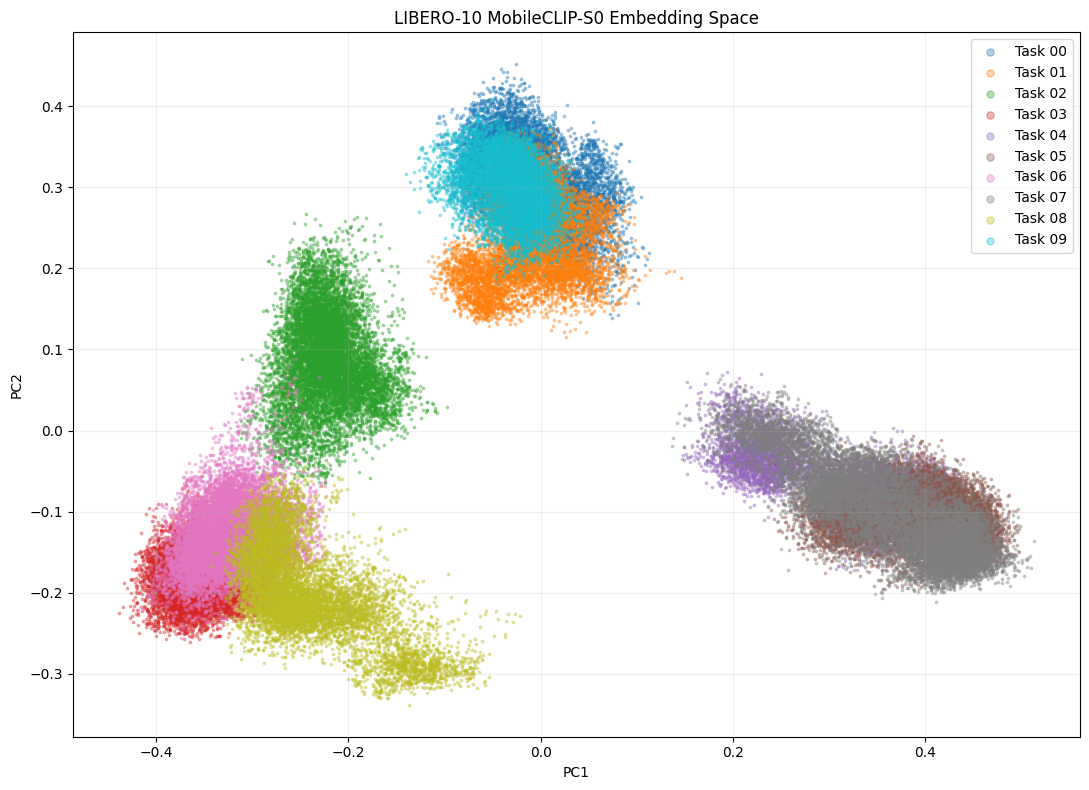

In [49]:
plt.figure(figsize=(11, 8))

for task_id in np.unique(tasks):
    mask = tasks == task_id

    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=3,
        alpha=0.35,
        label=f"Task {task_id:02d}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LIBERO-10 MobileCLIP-S0 Embedding Space")
plt.legend(markerscale=3)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [50]:
import torch
import numpy as np

PATH = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(PATH, map_location="cpu")

emb = data["embeddings"]      # [101469, 512]
task = data["task_ids"]
episode = data["episode_ids"]
frame = data["frame_ids"]
indices = data["indices"]

print("embedding:", emb.shape)
print("dtype:", emb.dtype)
print("RAM:", emb.numel() * emb.element_size() / 1024**2, "MB")


embedding: torch.Size([101469, 512])
dtype: torch.float32
RAM: 198.181640625 MB


In [51]:
# 最初の10,000 frameだけで確認
N = min(10000, len(emb))

a = emb[:N-1].float()
b = emb[1:N].float()

sim = (a * b).sum(dim=1)

print("=== Consecutive Frame Similarity ===")
print("mean:", sim.mean().item())
print("std :", sim.std().item())
print("min :", sim.min().item())
print("max :", sim.max().item())


=== Consecutive Frame Similarity ===
mean: 0.9922506809234619
std : 0.016590377315878868
min : 0.5829141139984131
max : 0.9999303817749023


In [52]:
import torch

N = len(emb)

a = emb[:-1].float()
b = emb[1:].float()

sim = (a * b).sum(dim=1)

# similarityが低い順
values, positions = torch.topk(
    sim,
    k=30,
    largest=False
)

print("=== Lowest Consecutive Similarities ===")

for rank, (s, p) in enumerate(zip(values, positions)):
    p = int(p)

    print(
        f"{rank+1:02d}: "
        f"sim={s.item():.4f} | "
        f"idx={p}->{p+1} | "
        f"task={int(task[p])}->{int(task[p+1])} | "
        f"episode={int(episode[p])}->{int(episode[p+1])} | "
        f"frame={int(frame[p])}->{int(frame[p+1])}"
    )
same_episode = episode[:-1] == episode[1:]

sim_inside_episode = sim[same_episode]

print("=== Within-Episode Consecutive Similarity ===")
print("count:", len(sim_inside_episode))
print("mean:", sim_inside_episode.mean().item())
print("std :", sim_inside_episode.std().item())
print("min :", sim_inside_episode.min().item())
print("max :", sim_inside_episode.max().item())
same_task = task[:-1] == task[1:]

print("Same task:", same_task.sum().item())
print("Task boundary:", (~same_task).sum().item())

print("Same episode:", same_episode.sum().item())
print("Episode boundary:", (~same_episode).sum().item())


=== Lowest Consecutive Similarities ===
01: sim=0.5082 | idx=96386->96387 | task=3->5 | episode=358->359 | frame=249->0
02: sim=0.5102 | idx=21284->21285 | task=8->7 | episode=75->76 | frame=239->0
03: sim=0.5261 | idx=76249->76250 | task=6->7 | episode=283->284 | frame=407->0
04: sim=0.5282 | idx=65662->65663 | task=3->7 | episode=243->244 | frame=298->0
05: sim=0.5363 | idx=31996->31997 | task=6->7 | episode=115->116 | frame=372->0
06: sim=0.5366 | idx=58225->58226 | task=6->7 | episode=214->215 | frame=387->0
07: sim=0.5407 | idx=85955->85956 | task=8->7 | episode=319->320 | frame=236->0
08: sim=0.5415 | idx=54020->54021 | task=8->5 | episode=198->199 | frame=234->0
09: sim=0.5416 | idx=28112->28113 | task=6->5 | episode=100->101 | frame=391->0
10: sim=0.5436 | idx=10855->10856 | task=3->5 | episode=38->39 | frame=260->0
11: sim=0.5457 | idx=68681->68682 | task=8->4 | episode=255->256 | frame=290->0
12: sim=0.5484 | idx=80271->80272 | task=9->8 | episode=299->300 | frame=188->0
13: 

In [53]:
import torch
import torch.nn.functional as F

emb_f = emb.float()

unique_tasks = torch.unique(task)

# --------------------------------
# Task prototype
# --------------------------------
prototypes = []

for t in unique_tasks:
    mask = task == t

    p = emb_f[mask].mean(dim=0)
    p = F.normalize(p, dim=0)

    prototypes.append(p)

prototypes = torch.stack(prototypes)

# --------------------------------
# Task-to-task similarity
# --------------------------------
task_sim = prototypes @ prototypes.T

print("=== TASK PROTOTYPE SIMILARITY ===")

print("      " + " ".join([f"{int(t):6d}" for t in unique_tasks]))

for i, t in enumerate(unique_tasks):
    row = " ".join([f"{v:.3f}" for v in task_sim[i]])
    print(f"{int(t):02d} : {row}")
# --------------------------------
# Within-task similarity
# --------------------------------

print("\n=== WITHIN TASK SPREAD ===")

for t in unique_tasks:
    mask = task == t

    x = emb_f[mask]

    # task prototype
    p = prototypes[(unique_tasks == t).nonzero(as_tuple=True)[0][0]]

    sims = x @ p

    print(
        f"task {int(t):02d}: "
        f"N={len(x):5d} "
        f"mean={sims.mean():.4f} "
        f"std={sims.std():.4f} "
        f"min={sims.min():.4f}"
    )


=== TASK PROTOTYPE SIMILARITY ===
           0      1      2      3      4      5      6      7      8      9
00 : 1.000 0.935 0.863 0.769 0.810 0.783 0.812 0.796 0.747 0.863
01 : 0.935 1.000 0.807 0.790 0.821 0.776 0.809 0.793 0.758 0.831
02 : 0.863 0.807 1.000 0.852 0.756 0.712 0.899 0.738 0.874 0.865
03 : 0.769 0.790 0.852 1.000 0.702 0.663 0.965 0.681 0.880 0.724
04 : 0.810 0.821 0.756 0.702 1.000 0.966 0.735 0.972 0.751 0.783
05 : 0.783 0.776 0.712 0.663 0.966 1.000 0.693 0.990 0.710 0.737
06 : 0.812 0.809 0.899 0.965 0.735 0.693 1.000 0.714 0.918 0.772
07 : 0.796 0.793 0.738 0.681 0.972 0.990 0.714 1.000 0.736 0.755
08 : 0.747 0.758 0.874 0.880 0.751 0.710 0.918 0.736 1.000 0.757
09 : 0.863 0.831 0.865 0.724 0.783 0.737 0.772 0.755 0.757 1.000

=== WITHIN TASK SPREAD ===
task 00: N= 9807 mean=0.9560 std=0.0140 min=0.8838
task 01: N= 9020 mean=0.9157 std=0.0264 min=0.8000
task 02: N= 9990 mean=0.9493 std=0.0154 min=0.8610
task 03: N=10866 mean=0.9516 std=0.0170 min=0.8316
task 04:

In [54]:
import torch
import numpy as np

PATH = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(PATH, map_location="cpu")

embeddings = data["embeddings"].float()
task_ids = data["task_ids"]
episode_ids = data["episode_ids"]
frame_ids = data["frame_ids"]
indices = data["indices"]

print("embeddings:", embeddings.shape)
print("task_ids:", task_ids.shape)
print("episodes:", episode_ids.shape)

# 念のため正規化
embeddings = torch.nn.functional.normalize(embeddings, dim=1)

print("RAM:", embeddings.numel() * 4 / 1024**2, "MB")


embeddings: torch.Size([101469, 512])
task_ids: torch.Size([101469])
episodes: torch.Size([101469])
RAM: 198.181640625 MB


In [55]:
num_tasks = int(task_ids.max().item()) + 1

task_centroids = []

for t in range(num_tasks):
    mask = task_ids == t
    z = embeddings[mask]

    centroid = z.mean(dim=0)
    centroid = torch.nn.functional.normalize(centroid, dim=0)

    task_centroids.append(centroid)

task_centroids = torch.stack(task_centroids)

print("Task centroids:", task_centroids.shape)


Task centroids: torch.Size([10, 512])


In [56]:
task_sim = task_centroids @ task_centroids.T

print("=== TASK CENTROID SIMILARITY ===")

for i in range(num_tasks):
    row = " ".join(
        f"{task_sim[i,j]:.3f}"
        for j in range(num_tasks)
    )
    print(f"{i:02d}: {row}")


=== TASK CENTROID SIMILARITY ===
00: 1.000 0.935 0.863 0.769 0.810 0.783 0.812 0.796 0.747 0.863
01: 0.935 1.000 0.807 0.790 0.821 0.776 0.809 0.793 0.758 0.831
02: 0.863 0.807 1.000 0.852 0.756 0.712 0.899 0.738 0.874 0.865
03: 0.769 0.790 0.852 1.000 0.702 0.663 0.965 0.681 0.880 0.724
04: 0.810 0.821 0.756 0.702 1.000 0.966 0.735 0.972 0.751 0.783
05: 0.783 0.776 0.712 0.663 0.966 1.000 0.693 0.990 0.710 0.737
06: 0.812 0.809 0.899 0.965 0.735 0.693 1.000 0.714 0.918 0.772
07: 0.796 0.793 0.738 0.681 0.972 0.990 0.714 1.000 0.736 0.755
08: 0.747 0.758 0.874 0.880 0.751 0.710 0.918 0.736 1.000 0.757
09: 0.863 0.831 0.865 0.724 0.783 0.737 0.772 0.755 0.757 1.000


In [57]:
episode_delta = torch.empty_like(embeddings)

unique_episodes = torch.unique(episode_ids)

for ep in unique_episodes:
    mask = episode_ids == ep

    z = embeddings[mask]

    # frame順に並んでいる前提
    base = z[0]

    episode_delta[mask] = z - base

print("Episode delta:", episode_delta.shape)
delta_norm = episode_delta.norm(dim=1)

print("=== EPISODE EMBEDDING CHANGE ===")
print("mean:", delta_norm.mean().item())
print("std :", delta_norm.std().item())
print("min :", delta_norm.min().item())
print("max :", delta_norm.max().item())


Episode delta: torch.Size([101469, 512])
=== EPISODE EMBEDDING CHANGE ===
mean: 0.45138686895370483
std : 0.13761399686336517
min : 0.0
max : 0.9107452034950256


In [58]:
def direction_similarity(a, b):
    d = task_centroids[b] - task_centroids[a]
    d = torch.nn.functional.normalize(d, dim=0)

    # 全episode変化とのsimilarity
    sims = episode_delta @ d

    return sims


# 例
for a, b in [(0, 1), (4, 5), (3, 6), (6, 8)]:
    d = task_centroids[b] - task_centroids[a]
    d = torch.nn.functional.normalize(d, dim=0)

    sim = episode_delta @ d

    print(
        f"{a}->{b}: "
        f"mean={sim.mean():.4f}, "
        f"std={sim.std():.4f}"
    )


0->1: mean=0.0895, std=0.0911
4->5: mean=-0.0481, std=0.0462
3->6: mean=0.0325, std=0.0499
6->8: mean=0.0223, std=0.0497


In [59]:
from datasets import load_dataset
import torch

dataset = load_dataset(
    "lerobot/libero_10_image",
    split="train"
)

print(dataset)
print(dataset[0]["observation.state"])


Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})
[-0.05338004603981972, 0.007029631175100803, 0.6783280968666077, 3.1407692432403564, 0.0017593271331861615, -0.08994418382644653, 0.03878866136074066, -0.03878721222281456]


In [60]:
states = torch.tensor(
    dataset["observation.state"],
    dtype=torch.float32
)

print("states:", states.shape)
print(states[:3])


states: torch.Size([101469, 8])
tensor([[-5.3380e-02,  7.0296e-03,  6.7833e-01,  3.1408e+00,  1.7593e-03,
         -8.9944e-02,  3.8789e-02, -3.8787e-02],
        [-5.3311e-02,  7.0271e-03,  6.7832e-01,  3.1408e+00,  1.7221e-03,
         -8.9667e-02,  3.8882e-02, -3.8881e-02],
        [-5.3207e-02,  7.0242e-03,  6.7830e-01,  3.1408e+00,  1.6998e-03,
         -8.9344e-02,  3.8936e-02, -3.8935e-02]])


In [61]:
import numpy as np

Z = embeddings.numpy()
S = states.numpy()

corr = np.corrcoef(
    Z.T,
    S.T
)[:512, 512:]

print("corr shape:", corr.shape)

for j in range(S.shape[1]):
    vals = np.abs(corr[:, j])

    top = np.argsort(vals)[-10:][::-1]

    print(f"\nSTATE DIM {j}")
    for k in top:
        print(
            f"  embedding[{k:3d}] "
            f"corr={corr[k,j]:+.4f}"
        )


corr shape: (512, 8)

STATE DIM 0
  embedding[327] corr=-0.5988
  embedding[  6] corr=-0.5608
  embedding[ 47] corr=-0.4936
  embedding[133] corr=-0.4790
  embedding[334] corr=-0.4565
  embedding[366] corr=-0.4552
  embedding[153] corr=+0.4464
  embedding[373] corr=-0.4441
  embedding[442] corr=+0.4390
  embedding[249] corr=+0.4297

STATE DIM 1
  embedding[346] corr=+0.5519
  embedding[349] corr=-0.4461
  embedding[335] corr=+0.4274
  embedding[246] corr=-0.4175
  embedding[276] corr=-0.4035
  embedding[107] corr=+0.3962
  embedding[ 86] corr=-0.3905
  embedding[ 44] corr=-0.3872
  embedding[175] corr=-0.3866
  embedding[360] corr=-0.3851

STATE DIM 2
  embedding[116] corr=+0.8083
  embedding[258] corr=+0.7999
  embedding[478] corr=+0.7808
  embedding[179] corr=+0.7805
  embedding[124] corr=+0.7527
  embedding[ 10] corr=-0.7463
  embedding[  4] corr=-0.7417
  embedding[341] corr=-0.7345
  embedding[111] corr=+0.7330
  embedding[327] corr=+0.7317

STATE DIM 3
  embedding[122] corr=+0.62

In [62]:
import torch
import numpy as np

Z = embeddings.clone()
S = states.clone()

# taskごとの平均を引く
Z_centered = torch.empty_like(Z)
S_centered = torch.empty_like(S)

for t in torch.unique(task_ids):
    mask = task_ids == t

    Z_centered[mask] = Z[mask] - Z[mask].mean(dim=0)
    S_centered[mask] = S[mask] - S[mask].mean(dim=0)

# correlation
Zc = Z_centered.numpy()
Sc = S_centered.numpy()

corr_within_task = np.corrcoef(
    Zc.T,
    Sc.T
)[:512, 512:]

print("=== WITHIN-TASK CORRELATION ===")

for j in range(8):
    vals = np.abs(corr_within_task[:, j])
    top = np.argsort(vals)[-10:][::-1]

    print(f"\nSTATE DIM {j}")

    for k in top:
        print(
            f"  embedding[{k:3d}] "
            f"corr={corr_within_task[k,j]:+.4f}"
        )


=== WITHIN-TASK CORRELATION ===

STATE DIM 0
  embedding[334] corr=-0.4906
  embedding[237] corr=+0.4365
  embedding[ 65] corr=+0.4055
  embedding[ 89] corr=-0.4042
  embedding[389] corr=-0.4001
  embedding[211] corr=+0.3918
  embedding[329] corr=+0.3910
  embedding[307] corr=+0.3842
  embedding[ 58] corr=-0.3699
  embedding[174] corr=-0.3627

STATE DIM 1
  embedding[346] corr=+0.5743
  embedding[426] corr=-0.5619
  embedding[413] corr=+0.5570
  embedding[ 55] corr=-0.5548
  embedding[ 86] corr=-0.5391
  embedding[314] corr=+0.5275
  embedding[223] corr=+0.4997
  embedding[360] corr=-0.4977
  embedding[256] corr=-0.4918
  embedding[364] corr=-0.4777

STATE DIM 2
  embedding[310] corr=-0.6024
  embedding[ 63] corr=-0.5825
  embedding[433] corr=+0.5702
  embedding[329] corr=-0.5521
  embedding[276] corr=-0.5146
  embedding[ 42] corr=+0.5144
  embedding[  2] corr=-0.5083
  embedding[258] corr=+0.5053
  embedding[ 65] corr=-0.5028
  embedding[226] corr=-0.5009

STATE DIM 3
  embedding[126]

In [2]:
import torch
import numpy as np

# ============================================================
# Load
# ============================================================

path = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(path, map_location="cpu")

Z = data["embeddings"].float()       # [N, 512]
task_ids = data["task_ids"]
episode_ids = data["episode_ids"]
frame_ids = data["frame_ids"]

print("Z:", Z.shape)


# ============================================================
# Normalize
# ============================================================

Z = torch.nn.functional.normalize(Z, dim=1)


# ============================================================
# Load dataset
# ============================================================

from datasets import load_dataset

dataset = load_dataset(
    "lerobot/libero_10_image",
    split="train"
)

print(dataset)


# ============================================================
# State matrix
# ============================================================

states = torch.tensor(
    np.array(dataset["observation.state"]),
    dtype=torch.float32
)

print("states:", states.shape)


Z: torch.Size([101469, 512])


Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/147 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})
states: torch.Size([101469, 8])


In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

Z_np = Z.numpy()
S_np = states.numpy()

# episode単位でtrain/testを分離
groups = episode_ids.numpy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(Z_np, S_np, groups=groups)
)

print("train:", len(train_idx))
print("test :", len(test_idx))


# ============================================================
# Linear probe: embedding -> state
# ============================================================

results = []

for d in range(S_np.shape[1]):

    reg = Ridge(alpha=1.0)

    reg.fit(
        Z_np[train_idx],
        S_np[train_idx, d]
    )

    pred = reg.predict(Z_np[test_idx])

    r2 = r2_score(
        S_np[test_idx, d],
        pred
    )

    results.append(r2)

    print(
        f"state[{d}] R2 = {r2:+.4f}"
    )


train: 81424
test : 20045
state[0] R2 = +0.9051
state[1] R2 = +0.9268
state[2] R2 = +0.9885
state[3] R2 = +0.8088
state[4] R2 = +0.8913
state[5] R2 = +0.7642
state[6] R2 = +0.5845
state[7] R2 = +0.5824


In [4]:
# ============================================================
# Fit multivariate state decoder
# ============================================================

from sklearn.linear_model import Ridge

decoder = Ridge(alpha=1.0)

decoder.fit(
    Z_np[train_idx],
    S_np[train_idx]
)

# decoder coefficients
W = torch.tensor(
    decoder.coef_,
    dtype=torch.float32
)

print("W:", W.shape)


W: torch.Size([8, 512])


In [5]:
from sklearn.cross_decomposition import CCA

cca = CCA(
    n_components=8,
    max_iter=1000
)

cca.fit(
    Z_np[train_idx],
    S_np[train_idx]
)

Z_test_cca, S_test_cca = cca.transform(
    Z_np[test_idx],
    S_np[test_idx]
)

print("Canonical correlations:")

for i in range(8):
    corr = np.corrcoef(
        Z_test_cca[:, i],
        S_test_cca[:, i]
    )[0, 1]

    print(
        f"component {i}: {corr:.4f}"
    )


Canonical correlations:
component 0: 0.9967
component 1: 0.9727
component 2: 0.9494
component 3: 0.9461
component 4: 0.8442
component 5: 0.8000
component 6: 0.7343
component 7: 0.2844


In [6]:
import torch
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# Z / state
# ============================================================

Z_np = Z.numpy().astype(np.float32)
S_np = states.numpy().astype(np.float32)

groups = episode_ids.numpy()

print("Z:", Z_np.shape)
print("S:", S_np.shape)


# ============================================================
# CCA
# ============================================================

n_components = 8

cca = CCA(
    n_components=n_components,
    max_iter=1000
)

cca.fit(
    Z_np[train_idx],
    S_np[train_idx]
)

Ztr_cca, Str_cca = cca.transform(
    Z_np[train_idx],
    S_np[train_idx]
)

Zte_cca, Ste_cca = cca.transform(
    Z_np[test_idx],
    S_np[test_idx]
)

print("CCA shape:", Ztr_cca.shape)


# ============================================================
# Canonical correlations
# ============================================================

print("\n=== CANONICAL CORRELATIONS ===")

cca_corrs = []

for i in range(n_components):
    c = np.corrcoef(
        Zte_cca[:, i],
        Ste_cca[:, i]
    )[0, 1]

    cca_corrs.append(c)

    print(f"{i}: {c:.4f}")


# ============================================================
# Remove CCA state-shared subspace
#
# CCA.transform gives coordinates in the CCA basis.
# We remove the first K canonical directions from Z.
# ============================================================

K = 7

# x_weights_ : [512, K]
# CCA canonical directions in original Z space
Wcca = cca.x_weights_[:, :K]

# Orthonormalize these directions
Q, _ = np.linalg.qr(Wcca)

print("\nQ shape:", Q.shape)

# projection onto state-shared subspace
P = Q @ Q.T

# residual
Ztr_res = Z_np[train_idx] - Z_np[train_idx] @ P
Zte_res = Z_np[test_idx]  - Z_np[test_idx]  @ P

print("\n=== RESIDUAL ===")
print("original:", Z_np[train_idx].shape)
print("residual:", Ztr_res.shape)


# ============================================================
# Variance retained
# ============================================================

orig_var = np.mean(np.sum(Z_np[train_idx] ** 2, axis=1))
res_var  = np.mean(np.sum(Ztr_res ** 2, axis=1))

print("\n=== ENERGY ===")
print("original energy :", orig_var)
print("residual energy :", res_var)
print("retained ratio  :", res_var / orig_var)


# ============================================================
# Re-normalize residual
# ============================================================

def normalize_np(x):
    return x / (
        np.linalg.norm(x, axis=1, keepdims=True) + 1e-8
    )

Ztr_res_n = normalize_np(Ztr_res)
Zte_res_n = normalize_np(Zte_res)


# ============================================================
# State probe AFTER removing state-shared subspace
# ============================================================

print("\n=== STATE PROBE AFTER REMOVAL ===")

for d in range(S_np.shape[1]):

    reg = Ridge(alpha=1.0)

    reg.fit(
        Ztr_res_n,
        S_np[train_idx, d]
    )

    pred = reg.predict(Zte_res_n)

    r2 = r2_score(
        S_np[test_idx, d],
        pred
    )

    print(f"state[{d}] R2 = {r2:+.4f}")


Z: (101469, 512)
S: (101469, 8)
CCA shape: (81424, 8)

=== CANONICAL CORRELATIONS ===
0: 0.9967
1: 0.9727
2: 0.9494
3: 0.9461
4: 0.8442
5: 0.8000
6: 0.7343
7: 0.2844

Q shape: (512, 7)

=== RESIDUAL ===
original: (81424, 512)
residual: (81424, 512)

=== ENERGY ===
original energy : 1.0
residual energy : 0.9952809659326125
retained ratio  : 0.9952809659326125

=== STATE PROBE AFTER REMOVAL ===
state[0] R2 = +0.8995
state[1] R2 = +0.9192
state[2] R2 = +0.9877
state[3] R2 = +0.8056
state[4] R2 = +0.8859
state[5] R2 = +0.7584
state[6] R2 = +0.5750
state[7] R2 = +0.5717


In [9]:
import numpy as np
import torch

S = torch.from_numpy(
    np.asarray(dataset["observation.state"], dtype=np.float32)
)

print("S:", S.shape, S.dtype)
print(S[:2])


S: torch.Size([101469, 8]) torch.float32
tensor([[-5.3380e-02,  7.0296e-03,  6.7833e-01,  3.1408e+00,  1.7593e-03,
         -8.9944e-02,  3.8789e-02, -3.8787e-02],
        [-5.3311e-02,  7.0271e-03,  6.7832e-01,  3.1408e+00,  1.7221e-03,
         -8.9667e-02,  3.8882e-02, -3.8881e-02]])


In [10]:
import torch
import numpy as np

N = Z.shape[0]
D = Z.shape[1]

# 再現可能なランダムサンプル
rng = np.random.default_rng(42)

train_idx = torch.from_numpy(
    rng.choice(N, size=10000, replace=False)
).long()

print("train samples:", len(train_idx))

# --------------------------------------------
# State
# --------------------------------------------

S_train = S[train_idx].float()

s_mean = S_train.mean(dim=0)
s_std = S_train.std(dim=0).clamp_min(1e-6)

X = (S_train - s_mean) / s_std

# --------------------------------------------
# MobileCLIP embedding
# --------------------------------------------

Y = Z[train_idx].float()

print("X:", X.shape)
print("Y:", Y.shape)

# --------------------------------------------
# Ridge regression
#
# X [10000, 8]
# Y [10000, 512]
# W [8, 512]
# --------------------------------------------

lam = 1e-2

XtX = X.T @ X
XtY = X.T @ Y

W = torch.linalg.solve(
    XtX + lam * torch.eye(8),
    XtY
)

print("W:", W.shape)


train samples: 10000
X: torch.Size([10000, 8])
Y: torch.Size([10000, 512])
W: torch.Size([8, 512])


In [11]:
with torch.no_grad():

    Y_pred = X @ W

    # embedding各次元についてR²
    ss_res = ((Y - Y_pred) ** 2).sum(dim=0)
    ss_tot = ((Y - Y.mean(dim=0)) ** 2).sum(dim=0)

    r2 = 1.0 - ss_res / ss_tot.clamp_min(1e-12)

print("=== STATE -> EMBEDDING R2 ===")
print("mean:", r2.mean().item())
print("std :", r2.std().item())
print("max :", r2.max().item())
print("min :", r2.min().item())

print("\nTop 20 embedding dimensions:")
top = torch.argsort(r2, descending=True)[:20]

for i in top:
    print(
        f"embedding[{i.item():3d}] "
        f"R2={r2[i].item():+.4f}"
    )


=== STATE -> EMBEDDING R2 ===
mean: -2.8430185317993164
std : 10.41295051574707
max : 0.6180052757263184
min : -127.03427124023438

Top 20 embedding dimensions:
embedding[478] R2=+0.6180
embedding[381] R2=+0.5799
embedding[205] R2=+0.5710
embedding[274] R2=+0.5623
embedding[122] R2=+0.5556
embedding[451] R2=+0.5548
embedding[124] R2=+0.5183
embedding[507] R2=+0.5116
embedding[353] R2=+0.4943
embedding[436] R2=+0.4900
embedding[333] R2=+0.4866
embedding[441] R2=+0.4837
embedding[140] R2=+0.4764
embedding[189] R2=+0.4697
embedding[214] R2=+0.4616
embedding[  4] R2=+0.4577
embedding[456] R2=+0.4455
embedding[157] R2=+0.4443
embedding[511] R2=+0.4384
embedding[ 74] R2=+0.4342


In [12]:
# ============================================
# TEST: state -> embedding
# ============================================

rng = np.random.default_rng(123)

test_idx = torch.from_numpy(
    rng.choice(N, size=10000, replace=False)
).long()

# trainとの重複チェック
print(
    "overlap:",
    len(set(train_idx.tolist()) & set(test_idx.tolist()))
)

S_test = S[test_idx].float()
Z_test = Z[test_idx].float()

X_test = (S_test - s_mean) / s_std

with torch.no_grad():
    Z_pred = X_test @ W

ss_res = ((Z_test - Z_pred) ** 2).sum(dim=0)
ss_tot = ((Z_test - Z_test.mean(dim=0)) ** 2).sum(dim=0)

r2_test = 1.0 - ss_res / ss_tot.clamp_min(1e-8)

print("=== TEST STATE -> EMBEDDING R2 ===")
print("mean:", r2_test.mean().item())
print("std :", r2_test.std().item())
print("max :", r2_test.max().item())
print("min :", r2_test.min().item())

print("\nTop 20:")
top = torch.argsort(r2_test, descending=True)[:20]

for i in top:
    print(
        f"embedding[{i.item():3d}] "
        f"R2={r2_test[i].item():+.4f}"
    )


overlap: 925
=== TEST STATE -> EMBEDDING R2 ===
mean: -2.8384616374969482
std : 10.336166381835938
max : 0.6023814678192139
min : -126.0083999633789

Top 20:
embedding[478] R2=+0.6024
embedding[381] R2=+0.5732
embedding[122] R2=+0.5584
embedding[205] R2=+0.5583
embedding[274] R2=+0.5568
embedding[451] R2=+0.5545
embedding[507] R2=+0.5103
embedding[353] R2=+0.5047
embedding[124] R2=+0.5036
embedding[436] R2=+0.5001
embedding[333] R2=+0.4887
embedding[441] R2=+0.4841
embedding[  4] R2=+0.4768
embedding[189] R2=+0.4741
embedding[214] R2=+0.4580
embedding[140] R2=+0.4533
embedding[265] R2=+0.4481
embedding[448] R2=+0.4420
embedding[456] R2=+0.4387
embedding[ 74] R2=+0.4376


In [13]:
import torch

# CPUで計算
Z_cpu = Z.float().cpu()
S_cpu = S.float().cpu()

# train/test split
N = Z_cpu.shape[0]
perm = torch.randperm(N, generator=torch.Generator().manual_seed(42))

n_train = int(N * 0.8)

train_idx = perm[:n_train]
test_idx  = perm[n_train:]

Ztr = Z_cpu[train_idx]
Str = S_cpu[train_idx]

Zte = Z_cpu[test_idx]
Ste = S_cpu[test_idx]

print("train:", Ztr.shape)
print("test :", Zte.shape)


train: torch.Size([81175, 512])
test : torch.Size([20294, 512])


In [14]:
# stateを標準化
S_mean = Str.mean(dim=0, keepdim=True)
S_std  = Str.std(dim=0, keepdim=True).clamp_min(1e-6)

Str_n = (Str - S_mean) / S_std
Ste_n = (Ste - S_mean) / S_std

# bias込み
Xtr = torch.cat([
    Str_n,
    torch.ones(len(Str_n), 1)
], dim=1)

Xte = torch.cat([
    Ste_n,
    torch.ones(len(Ste_n), 1)
], dim=1)

# ridge regression
lam = 1e-3

XtX = Xtr.T @ Xtr
I = torch.eye(XtX.shape[0])

W = torch.linalg.solve(
    XtX + lam * I,
    Xtr.T @ Ztr
)

print("W:", W.shape)


W: torch.Size([9, 512])


In [15]:
Ztr_pred = Xtr @ W
Zte_pred = Xte @ W

Ztr_res = Ztr - Ztr_pred
Zte_res = Zte - Zte_pred

print("residual train:", Ztr_res.shape)
print("residual test :", Zte_res.shape)


residual train: torch.Size([81175, 512])
residual test : torch.Size([20294, 512])


In [16]:
def r2_score_per_dim(y, pred):
    ss_res = ((y - pred) ** 2).sum(dim=0)
    ss_tot = ((y - y.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)
    return 1.0 - ss_res / ss_tot

r2_before = r2_score_per_dim(
    Zte,
    Zte_pred
)

r2_after = r2_score_per_dim(
    Zte_res,
    torch.zeros_like(Zte_res)
)

print("mean R2 before:", r2_before.mean().item())
print("max  R2 before:", r2_before.max().item())

print("residual variance ratio:",
      Zte_res.var(dim=0).mean().item() /
      Zte.var(dim=0).mean().item())


mean R2 before: 0.28277817368507385
max  R2 before: 0.6815358400344849
residual variance ratio: 0.6856799836143501


In [17]:
task = task_ids[test_idx].cpu()

tasks = torch.unique(task).tolist()

centroids = []

for t in tasks:
    mask = task == t
    c = Zte_res[mask].mean(dim=0)
    c = c / c.norm()
    centroids.append(c)

C = torch.stack(centroids)

sim = C @ C.T

print("=== RESIDUAL TASK CENTROID SIMILARITY ===")

for i, t in enumerate(tasks):
    row = " ".join(f"{sim[i,j]:.3f}" for j in range(len(tasks)))
    print(f"{t:02d}: {row}")


=== RESIDUAL TASK CENTROID SIMILARITY ===
00: 1.000 0.559 0.481 -0.005 -0.699 -0.735 0.098 -0.713 -0.189 -0.087
01: 0.559 1.000 0.110 0.231 -0.604 -0.805 0.220 -0.867 -0.030 -0.016
02: 0.481 0.110 1.000 -0.251 -0.318 -0.320 -0.506 -0.199 -0.180 0.073
03: -0.005 0.231 -0.251 1.000 -0.194 -0.232 0.670 -0.386 0.207 -0.744
04: -0.699 -0.604 -0.318 -0.194 1.000 0.478 -0.149 0.523 0.034 0.128
05: -0.735 -0.805 -0.320 -0.232 0.478 1.000 -0.124 0.849 0.016 0.061
06: 0.098 0.220 -0.506 0.670 -0.149 -0.124 1.000 -0.324 -0.172 -0.611
07: -0.713 -0.867 -0.199 -0.386 0.523 0.849 -0.324 1.000 -0.051 0.287
08: -0.189 -0.030 -0.180 0.207 0.034 0.016 -0.172 -0.051 1.000 -0.397
09: -0.087 -0.016 0.073 -0.744 0.128 0.061 -0.611 0.287 -0.397 1.000


In [18]:
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# CPU
Z_original = Zte.float().cpu()
Z_residual = Zte_res.float().cpu()
y = task_ids[test_idx].long().cpu()

print("Original :", Z_original.shape)
print("Residual :", Z_residual.shape)
print("Labels   :", y.shape)

# 少し軽くするため、必要なら512 -> 128次元
# 今回はまず512のまま


Original : torch.Size([20294, 512])
Residual : torch.Size([20294, 512])
Labels   : torch.Size([20294])


In [19]:
clf_orig = LogisticRegression(
    max_iter=300,
    C=1.0,
    solver="lbfgs"
)

clf_res = LogisticRegression(
    max_iter=300,
    C=1.0,
    solver="lbfgs"
)

# train側
y_train = task_ids[train_idx].long().cpu()

clf_orig.fit(Ztr.numpy(), y_train.numpy())
clf_res.fit(Ztr_res.numpy(), y_train.numpy())

pred_orig = clf_orig.predict(Z_original.numpy())
pred_res  = clf_res.predict(Z_residual.numpy())

acc_orig = accuracy_score(y.numpy(), pred_orig)
acc_res  = accuracy_score(y.numpy(), pred_res)

print("=== TASK LINEAR PROBE ===")
print(f"Original Z : {acc_orig:.4f}")
print(f"Residual Z : {acc_res:.4f}")
print(f"Drop       : {acc_orig - acc_res:+.4f}")


=== TASK LINEAR PROBE ===
Original Z : 0.9912
Residual Z : 0.9897
Drop       : +0.0016


In [20]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# =========================
# 1. Load embeddings
# =========================

path = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(path, map_location="cpu")

Z = data["embeddings"].float()
task_ids = data["task_ids"].long()
episode_ids = data["episode_ids"].long()

print("Z:", Z.shape)
print("task_ids:", task_ids.shape)

# =========================
# 2. Load state
# =========================

# dataset が既にある場合は再利用
# なければこのセルでは止める
assert "dataset" in globals(), \
    "dataset がありません。前のLIBERO dataset loadingセルを先に実行してください。"

S = torch.tensor(
    np.asarray(dataset["observation.state"]),
    dtype=torch.float32
)

print("S:", S.shape)

# =========================
# 3. Train/test split
# =========================

N = Z.shape[0]

rng = np.random.RandomState(42)
perm = rng.permutation(N)

n_train = int(N * 0.8)

train_idx = perm[:n_train]
test_idx  = perm[n_train:]

print("train:", len(train_idx))
print("test :", len(test_idx))


Z: torch.Size([101469, 512])
task_ids: torch.Size([101469])
S: torch.Size([101469, 8])
train: 81175
test : 20294


In [21]:
# =========================
# 4. State regression
# =========================

Z_train = Z[train_idx]
S_train = S[train_idx]

# 中心化
Z_mean = Z_train.mean(dim=0)
S_mean = S_train.mean(dim=0)

Zc = Z_train - Z_mean
Sc = S_train - S_mean

# S -> Z の線形回帰
# W: state -> embedding
W = torch.linalg.lstsq(Sc, Zc).solution

print("W:", W.shape)

# =========================
# 5. State-explainable component
# =========================

Z_state_train = Sc @ W
Z_res_train = Zc - Z_state_train

print("original:", Zc.shape)
print("residual:", Z_res_train.shape)

# =========================
# 6. Test residual
# =========================

Z_test = Z[test_idx]
S_test = S[test_idx]

Zc_test = Z_test - Z_mean
Sc_test = S_test - S_mean

Z_state_test = Sc_test @ W
Z_res_test = Zc_test - Z_state_test

print("test residual:", Z_res_test.shape)


W: torch.Size([8, 512])
original: torch.Size([81175, 512])
residual: torch.Size([81175, 512])
test residual: torch.Size([20294, 512])


In [22]:
# =========================
# 7. Task probe
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_train = task_ids[train_idx].numpy()
y_test  = task_ids[test_idx].numpy()

clf_orig = LogisticRegression(
    max_iter=1000,
    C=1.0,
    n_jobs=-1
)

clf_res = LogisticRegression(
    max_iter=1000,
    C=1.0,
    n_jobs=-1
)

clf_orig.fit(Zc.numpy(), y_train)
clf_res.fit(Z_res_train.numpy(), y_train)

pred_orig = clf_orig.predict(Zc_test.numpy())
pred_res  = clf_res.predict(Z_res_test.numpy())

print("=== TASK ACCURACY ===")
print("Original :", accuracy_score(y_test, pred_orig))
print("Residual :", accuracy_score(y_test, pred_res))


=== TASK ACCURACY ===
Original : 0.9925101015078348
Residual : 0.9923129989159357


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# =========================
# Load
# =========================

path = "/content/v5_checkpoints/libero10_mobileclip_s0_embeddings.pt"

data = torch.load(path, map_location="cpu")

Z = data["embeddings"].float()
task_ids = data["task_ids"].long()

print("Z:", Z.shape)
print("tasks:", torch.unique(task_ids).tolist())

# =========================
# Normalize
# =========================

Z = F.normalize(Z, dim=1)

# =========================
# Task centroid
# =========================

num_tasks = int(task_ids.max()) + 1

centroids = []

for t in range(num_tasks):
    zt = Z[task_ids == t]
    c = F.normalize(zt.mean(dim=0, keepdim=True), dim=1)
    centroids.append(c.squeeze(0))

centroids = torch.stack(centroids)

print("centroids:", centroids.shape)


Z: torch.Size([101469, 512])
tasks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
centroids: torch.Size([10, 512])


In [24]:
print(dataset)
print()

# DatasetDict / LeRobot dataset の構造によって違うので
# まず metadata を探索
print("Available attributes:")
print([x for x in dir(dataset) if "task" in x.lower() or "meta" in x.lower()])


Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})

Available attributes:
[]


In [25]:
import os
import glob

print("=== /content/v5_checkpoints ===")
for p in glob.glob("/content/v5_checkpoints/**/*", recursive=True):
    if os.path.isfile(p):
        name = os.path.basename(p).lower()
        if "task" in name or "meta" in name or "info" in name:
            print(p)

print("\n=== dataset object ===")
print(type(dataset))
print(dataset)


=== /content/v5_checkpoints ===

=== dataset object ===
<class 'datasets.arrow_dataset.Dataset'>
Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 101469
})


In [26]:
# dataset が HuggingFace Dataset なら、features / info 周辺を見る
print("INFO")
print(getattr(dataset, "info", None))

print("\nFEATURES")
print(dataset.features)

print("\nCOLUMN NAMES")
print(dataset.column_names)


INFO
DatasetInfo(description='', citation='', homepage='', license='', features={'observation.images.image': Image(mode=None, decode=True), 'observation.images.wrist_image': Image(mode=None, decode=True), 'observation.state': List(Value('float32')), 'action': List(Value('float32')), 'timestamp': Value('float32'), 'frame_index': Value('int64'), 'episode_index': Value('int64'), 'index': Value('int64'), 'task_index': Value('int64')}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='libero_10_image', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=12774039968, num_examples=101469, shard_lengths=[4670, 3908, 4671, 4422, 4463, 4485, 4492, 3986, 4457, 4337, 4232, 4346, 3983, 4055, 4368, 4095, 4043, 4299, 4235, 4172, 4360, 4458, 4496, 2436], dataset_name='libero_10_image')}, download_checksums={'hf://datasets/lerobot/libero_10_image@7e324b526699f444044952c82ce3f438e8d300d0/data/chunk-000/file-000.parquet': {'num_bytes': 1